<a href="https://colab.research.google.com/github/faisu6339-glitch/LLMs/blob/main/Self_Attention(All_types_of_programs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Program 1 — Simple Attention Without PyTorch

Start here before implementing the real thing.

In [1]:
import numpy as np

Q = np.array([
    [1, 0],
    [0, 1]
])

K = np.array([
    [1, 0],
    [0, 1]
])

V = np.array([
    [10, 20],
    [30, 40]
])

# Step 1: Calculate scores
scores = Q @ K.T

print("Scores:")
print(scores)

# Step 2: Softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(scores)

print("\nAttention Weights:")
print(attention_weights)

# Step 3: Weighted values
output = attention_weights @ V

print("\nOutput:")
print(output)

Scores:
[[1 0]
 [0 1]]

Attention Weights:
[[0.73105858 0.26894142]
 [0.26894142 0.73105858]]

Output:
[[15.37882843 25.37882843]
 [24.62117157 34.62117157]]


# Program 2 — Scaled Dot-Product Attention

Now implement the actual Transformer formula.

In [2]:
import numpy as np

def scaled_dot_product_attention(Q, K, V):

    d_k = K.shape[-1]

    # Calculate attention scores
    scores = Q @ K.T

    # Scale
    scores = scores / np.sqrt(d_k)

    # Softmax
    exp_scores = np.exp(
        scores - np.max(scores, axis=-1, keepdims=True)
    )

    attention_weights = (
        exp_scores /
        exp_scores.sum(axis=-1, keepdims=True)
    )

    # Weighted sum
    output = attention_weights @ V

    return output, attention_weights


Q = np.array([
    [1, 0],
    [0, 1]
])

K = np.array([
    [1, 0],
    [0, 1]
])

V = np.array([
    [10, 20],
    [30, 40]
])

output, weights = scaled_dot_product_attention(Q, K, V)

print("Attention Weights:")
print(weights)

print("\nOutput:")
print(output)

Attention Weights:
[[0.66976155 0.33023845]
 [0.33023845 0.66976155]]

Output:
[[16.60476901 26.60476901]
 [23.39523099 33.39523099]]


# Program 3 — Self-Attention using PyTorch

Now let's build it using PyTorch.

In [3]:
import torch
import torch.nn as nn

torch.manual_seed(42)

# 3 tokens, embedding dimension = 4
X = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0, 0.0]
])

d_model = 4

W_Q = nn.Linear(d_model, d_model)
W_K = nn.Linear(d_model, d_model)
W_V = nn.Linear(d_model, d_model)

Q = W_Q(X)
K = W_K(X)
V = W_V(X)

print("Q:")
print(Q)

print("\nK:")
print(K)

print("\nV:")
print(V)

# Attention scores
scores = Q @ K.T

# Scale
scores = scores / torch.sqrt(
    torch.tensor(d_model, dtype=torch.float32)
)

# Softmax
attention_weights = torch.softmax(scores, dim=-1)

# Output
output = attention_weights @ V

print("\nAttention Weights:")
print(attention_weights)

print("\nOutput:")
print(output)

Q:
tensor([[ 0.6506, -0.2791,  0.6419,  0.7379],
        [ 1.2598,  0.4684, -0.5067,  0.1246],
        [ 1.1827,  0.0652, -0.1595,  0.5646]], grad_fn=<AddmmBackward0>)

K:
tensor([[-0.3555, -0.1319,  0.5534,  0.0660],
        [ 0.3510, -0.1272, -0.8639,  0.2345],
        [-0.2111, -0.2212, -0.3920,  0.3115]], grad_fn=<AddmmBackward0>)

V:
tensor([[ 0.5029,  0.5690,  0.1503, -0.5948],
        [ 0.4690, -0.1378, -0.1066,  0.2621],
        [ 0.1569,  0.0617,  0.3405, -0.3285]], grad_fn=<AddmmBackward0>)

Attention Weights:
tensor([[0.3694, 0.3137, 0.3169],
        [0.2153, 0.4867, 0.2979],
        [0.2476, 0.4416, 0.3108]], grad_fn=<SoftmaxBackward0>)

Output:
tensor([[ 0.3826,  0.1865,  0.1300, -0.2416],
        [ 0.3833,  0.0738,  0.0819, -0.0983],
        [ 0.3804,  0.0992,  0.0959, -0.1336]], grad_fn=<MmBackward0>)


# Program 4 — Create a Self-Attention Class

In [4]:
import torch
import torch.nn as nn

class SelfAttention(nn.Module):

    def __init__(self, d_model):

        super().__init__()

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

    def forward(self, x):

        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        scores = Q @ K.transpose(-2, -1)

        d_k = Q.size(-1)

        scores = scores / (d_k ** 0.5)

        attention_weights = torch.softmax(
            scores,
            dim=-1
        )

        output = attention_weights @ V

        return output, attention_weights


x = torch.randn(1, 4, 8)

attention = SelfAttention(d_model=8)

output, weights = attention(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)
print("Attention shape:", weights.shape)

Input shape: torch.Size([1, 4, 8])
Output shape: torch.Size([1, 4, 8])
Attention shape: torch.Size([1, 4, 4])


# Program 5 — Visualize Attention

This is an excellent program for understanding self-attention.

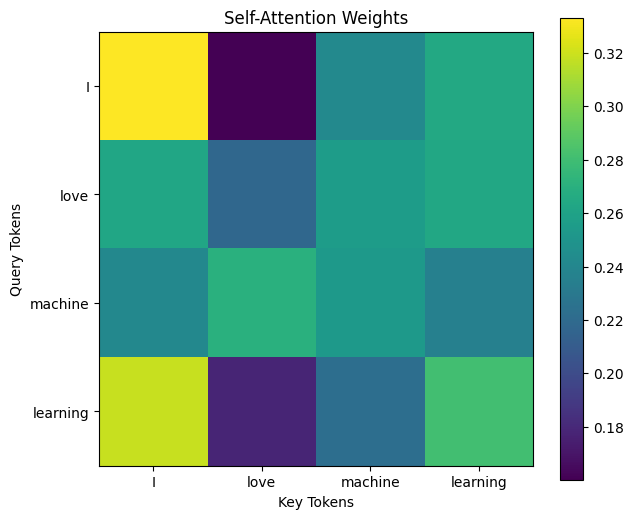

In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class SelfAttention(nn.Module):

    def __init__(self, d_model):
        super().__init__()

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

    def forward(self, x):

        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        scores = Q @ K.transpose(-2, -1)

        scores = scores / (Q.size(-1) ** 0.5)

        weights = torch.softmax(scores, dim=-1)

        output = weights @ V

        return output, weights


tokens = [
    "I",
    "love",
    "machine",
    "learning"
]

x = torch.randn(1, 4, 8)

model = SelfAttention(8)

output, weights = model(x)

weights = weights[0].detach().numpy()

plt.figure(figsize=(7, 6))

plt.imshow(weights)

plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Self-Attention Weights")

plt.colorbar()

plt.show()

# Program 6 — Self-Attention with Text

Now we move closer to an NLP/LLM application.

In [6]:
import torch
import torch.nn as nn

sentence = "I love machine learning"

tokens = sentence.split()

print(tokens)

vocab = {
    "I": 0,
    "love": 1,
    "machine": 2,
    "learning": 3
}

token_ids = torch.tensor([
    vocab[token] for token in tokens
])

print("Token IDs:", token_ids)

['I', 'love', 'machine', 'learning']
Token IDs: tensor([0, 1, 2, 3])


In [7]:
embedding = nn.Embedding(
    num_embeddings=4,
    embedding_dim=8
)

X = embedding(token_ids)

print(X.shape)

torch.Size([4, 8])


# Program 8 — Implement Causal Self-Attention

In [8]:
import torch
import torch.nn as nn

class CausalSelfAttention(nn.Module):

    def __init__(self, d_model):

        super().__init__()

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

    def forward(self, x):

        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        d_k = Q.size(-1)

        scores = Q @ K.transpose(-2, -1)

        scores = scores / (d_k ** 0.5)

        # Causal mask
        seq_len = x.size(1)

        mask = torch.triu(
            torch.ones(seq_len, seq_len),
            diagonal=1
        ).bool()

        scores = scores.masked_fill(
            mask,
            float("-inf")
        )

        weights = torch.softmax(
            scores,
            dim=-1
        )

        output = weights @ V

        return output, weights


x = torch.randn(1, 4, 8)

model = CausalSelfAttention(8)

output, weights = model(x)

print("Attention weights:")
print(weights)

Attention weights:
tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.5210, 0.4790, 0.0000, 0.0000],
         [0.2478, 0.3072, 0.4450, 0.0000],
         [0.2036, 0.2617, 0.2806, 0.2541]]], grad_fn=<SoftmaxBackward0>)


# Program 9 — PyTorch's Built-in Multi-Head Attention

Real Transformers don't normally use just one attention head.

They use Multi-Head Attention.

PyTorch provides:

In [9]:
import torch
import torch.nn as nn

d_model = 64
num_heads = 8

attention = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=num_heads,
    batch_first=True
)

x = torch.randn(2, 10, 64)

output, weights = attention(
    x,
    x,
    x
)

print("Input:", x.shape)
print("Output:", output.shape)
print("Attention:", weights.shape)

Input: torch.Size([2, 10, 64])
Output: torch.Size([2, 10, 64])
Attention: torch.Size([2, 10, 10])


# Program 10 — Build Multi-Head Attention Yourself

This is a very important advanced program.

In [10]:
import torch
import torch.nn as nn

class MultiHeadSelfAttention(nn.Module):

    def __init__(self, d_model, num_heads):

        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

        self.output_projection = nn.Linear(
            d_model,
            d_model
        )

    def forward(self, x):

        batch_size, seq_len, _ = x.shape

        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # Split into heads
        Q = Q.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        )

        K = K.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        )

        V = V.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.head_dim
        )

        # Move heads before sequence dimension
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Attention
        scores = Q @ K.transpose(-2, -1)

        scores = scores / (self.head_dim ** 0.5)

        weights = torch.softmax(
            scores,
            dim=-1
        )

        attention_output = weights @ V

        # Combine heads
        attention_output = attention_output.transpose(1, 2)

        attention_output = attention_output.contiguous()

        attention_output = attention_output.view(
            batch_size,
            seq_len,
            self.d_model
        )

        output = self.output_projection(
            attention_output
        )

        return output, weights


x = torch.randn(2, 10, 64)

model = MultiHeadSelfAttention(
    d_model=64,
    num_heads=8
)

output, weights = model(x)

print("Input:", x.shape)
print("Output:", output.shape)
print("Attention:", weights.shape)

Input: torch.Size([2, 10, 64])
Output: torch.Size([2, 10, 64])
Attention: torch.Size([2, 8, 10, 10])
